In [1]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 7.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df1 = pd.read_csv("/content/main_spredsheet_v2 - The Chamber Data.csv")
df2 = pd.read_csv("/content/main_spredsheet - The Chamber Data.csv")

df = pd.concat([df1, df2], ignore_index=True)

df = df.drop_duplicates()

df["Tempo_de_Decisao_s"] = (
    df["Tempo_de_Decisao_s"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

df = df.sort_values(by=["ID_Sessao", "Num_Rodada"]).reset_index(drop=True)

df.to_csv("/content/dados_combinados.csv", index=False)

print(df.head())


                ID_Sessao ID_Participante  Num_Rodada  Idade  \
0  SESSAO_1755042372_7229              P1           1     21   
1  SESSAO_1755042372_7229              P1           2     21   
2  SESSAO_1755042372_7229              P1           3     21   
3  SESSAO_1755042372_7229              P1           4     21   
4  SESSAO_1755042372_7229              P1           5     21   

  Genero_Participante  Experiencia_com_Jogos  ID_Caso Tipo_de_Historia  \
0           Homem cis                      4        1             Real   
1           Homem cis                      4        1             Real   
2           Homem cis                      4        1             Real   
3           Homem cis                      4        1             Real   
4           Homem cis                      4        1             Real   

  Genero_Suspeito  Tempo_de_Decisao_s  Decisao_Final  Mudanca_de_Voto  \
0        Feminino                6.74              0                0   
1        Feminino       

In [3]:
# so para contar quanto de cada versao a gnt tem
# df["Versão"].value_counts()
aux = df.drop_duplicates(subset=["ID_Sessao"])
print(aux["Versão"].value_counts())
print()

# ---------------------------
# 1. Total de rounds jogados (todas as linhas)
total_rounds = len(df)

# 2. Remover duplicatas para contar apenas jogadores únicos
jogadores_unicos = df.drop_duplicates(subset=["ID_Sessao"])

# 3. Número total de jogadores
total_players = len(jogadores_unicos)

# 4. Distribuição por gênero (apenas jogadores únicos)
genero_counts = jogadores_unicos['Genero_Participante'].value_counts()

# 5. Distribuição por idade (apenas jogadores únicos)
idade_counts = jogadores_unicos['Idade'].value_counts().sort_index()

# ---------------------------
# Exibir resultados
print(f"Total de rounds jogados: {total_rounds}")
print(f"Total de jogadores únicos: {total_players}")
print("\nDistribuição por gênero:")
print(genero_counts)
print("\nDistribuição por idade:")
print(idade_counts)


# === Limpeza mínima ===
# Padronizar tempo (se vier com vírgula)
if "Tempo_de_Decisao_s" in df.columns:
    df["Tempo_de_Decisao_s"] = (
        df["Tempo_de_Decisao_s"].astype(str).str.replace(",", ".").astype(float)
    )

# Criar coluna de acerto: decisão do jogador bate com o resultado real do caso?
# Colunas corretas da planilha: Decisao_Final (0/1) e Resultado_Real_Caso (0/1)
df["Acertou"] = (df["Decisao_Final"] == df["Resultado_Real_Caso"]).astype(int)

def matriz_confusao_por_genero_participante(dados: pd.DataFrame, genero_participante: str):
    sub = dados[dados["Genero_Participante"] == genero_participante].copy()
    # Contagens
    contagens = pd.crosstab(
        index=sub["Genero_Suspeito"],
        columns=sub["Acertou"],
        dropna=False
    ).rename(columns={0: "Erro", 1: "Acerto"})
    # Percentuais por linha
    percentuais = pd.crosstab(
        index=sub["Genero_Suspeito"],
        columns=sub["Acertou"],
        normalize="index",
        dropna=False
    ).rename(columns={0: "Erro_%", 1: "Acerto_%"})
    percentuais = (percentuais * 100).round(2)

    combinado = contagens.join(percentuais, how="outer")
    combinado.index.name = "Genero_Suspeito"
    return combinado.sort_index()

matrizes = {}
for g in ["Homem cis", "Mulher cis"]:
    if "Genero_Participante" in df.columns and g in df["Genero_Participante"].unique():
        matrizes[g] = matriz_confusao_por_genero_participante(df, g)

for g, tabela in matrizes.items():
    print(f"\n=== Matriz de confusão — Participantes {g} ===")
    print(tabela)

Versão
1    22
3    12
Name: count, dtype: int64

Total de rounds jogados: 1326
Total de jogadores únicos: 34

Distribuição por gênero:
Genero_Participante
Mulher cis    19
Homem cis     15
Name: count, dtype: int64

Distribuição por idade:
Idade
18    2
19    2
20    3
21    7
22    8
23    2
24    3
25    1
27    1
29    1
43    2
53    1
95    1
Name: count, dtype: int64

=== Matriz de confusão — Participantes Homem cis ===
Acertou          Erro  Acerto  Erro_%  Acerto_%
Genero_Suspeito                                
Feminino           79     185   29.92     70.08
Masculino          84     174   32.56     67.44

=== Matriz de confusão — Participantes Mulher cis ===
Acertou          Erro  Acerto  Erro_%  Acerto_%
Genero_Suspeito                                
Feminino          126     276   31.34     68.66
Masculino         159     243   39.55     60.45



Médias por caso e gênero do suspeito:
    ID_Caso Genero_Suspeito  Decisao_Final  Tempo_de_Decisao_s  \
0         1        Feminino       0.272727           39.202727   
1         1       Masculino       0.333333           64.843056   
2         2        Feminino       0.287879           35.677273   
3         2       Masculino       0.552632           27.042105   
4         3        Feminino       0.484848           37.612121   
5         3       Masculino       0.474359           36.084615   
6         4        Feminino       0.307692           55.343590   
7         4       Masculino       0.393939           78.090909   
8         5        Feminino       0.696970           34.492424   
9         5       Masculino       0.818182           82.709091   
10        6        Feminino       0.185185           35.453704   
11        6       Masculino       0.333333           28.300000   
12        7        Feminino       0.812500           20.808333   
13        7       Masculino       0.7

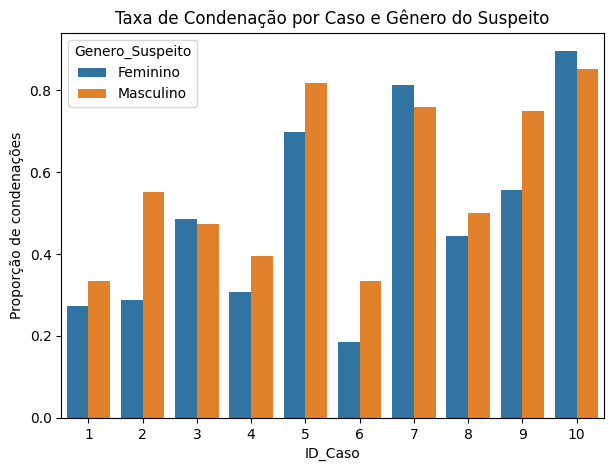

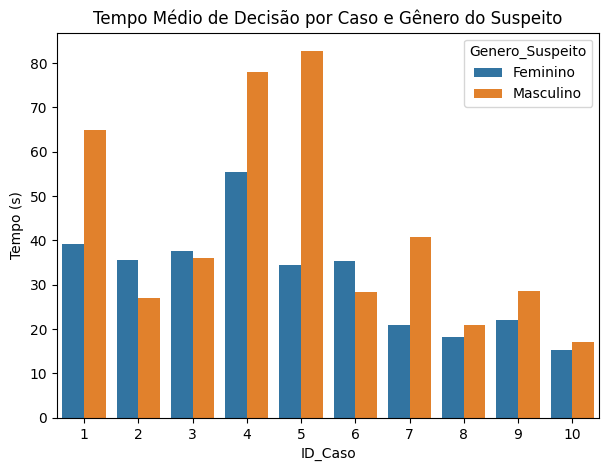

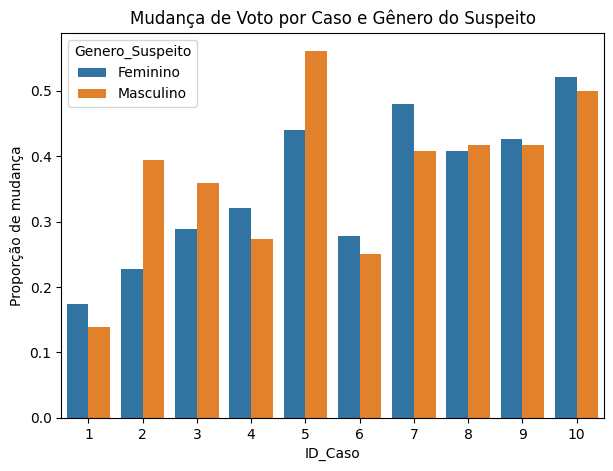


Testes de diferença por caso:
   ID_Caso         t         p
0        1  0.889345  0.375357
1        2  3.622405  0.000402
2        3 -0.124656  0.900977
3        4  1.074772  0.284393
4        5  1.628822  0.105844
5        6  1.821717  0.071186
6        7 -0.650919  0.516593
7        8  0.556171  0.579356
8        9  2.090908  0.039072
9       10 -0.665578  0.507215


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Agrupar por caso e versão para ver médias
agrupado = df.groupby(["ID_Caso", "Genero_Suspeito"]).agg({
    "Decisao_Final": "mean",
    "Tempo_de_Decisao_s": "mean",
    "Mudanca_de_Voto": "mean"
}).reset_index()

print("\nMédias por caso e gênero do suspeito:")
print(agrupado)

# ---- Gráficos ----
plt.figure(figsize=(7,5))
sns.barplot(x="ID_Caso", y="Decisao_Final", hue="Genero_Suspeito", data=agrupado)
plt.title("Taxa de Condenação por Caso e Gênero do Suspeito")
plt.ylabel("Proporção de condenações")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x="ID_Caso", y="Tempo_de_Decisao_s", hue="Genero_Suspeito", data=agrupado)
plt.title("Tempo Médio de Decisão por Caso e Gênero do Suspeito")
plt.ylabel("Tempo (s)")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x="ID_Caso", y="Mudanca_de_Voto", hue="Genero_Suspeito", data=agrupado)
plt.title("Mudança de Voto por Caso e Gênero do Suspeito")
plt.ylabel("Proporção de mudança")
plt.show()

# ---- Testes estatísticos (comparando gêneros dentro de cada caso) ----

print("\nTestes de diferença por caso:")
resultados = []
for caso in df["ID_Caso"].unique():
    sub = df[df["ID_Caso"] == caso]
    masc = sub[sub["Genero_Suspeito"] == "Masculino"]["Decisao_Final"]
    fem  = sub[sub["Genero_Suspeito"] == "Feminino"]["Decisao_Final"]
    if len(masc) > 1 and len(fem) > 1:
        t, p = stats.ttest_ind(masc, fem, equal_var=False)
        resultados.append({"ID_Caso": caso, "t": t, "p": p})


resultados_df = pd.DataFrame(resultados)
print(resultados_df)


Tabela de acusações finais (apenas última rodada) por gênero do jogador e gênero do suspeito:
Genero_Suspeito      Feminino  Masculino
Genero_Participante                     
Homem cis                  18         24
Mulher cis                 32         40


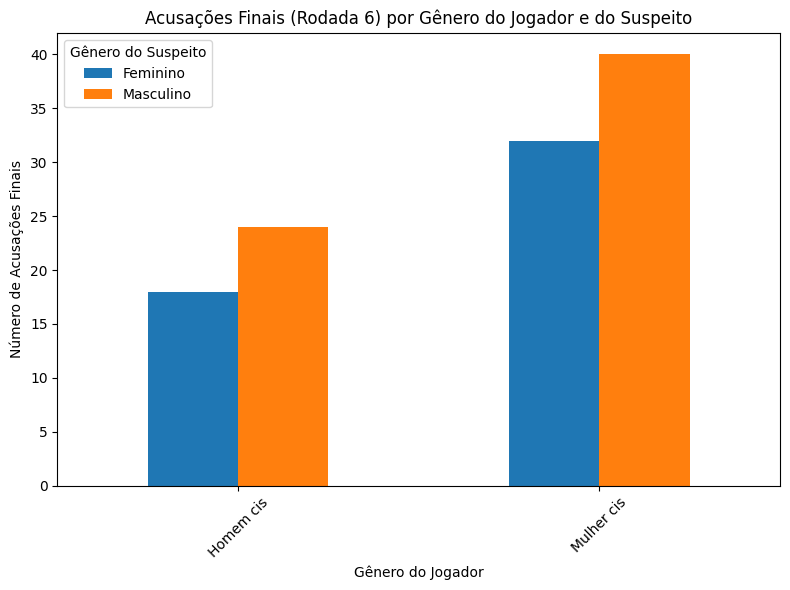

In [5]:
# Filtrar apenas a última rodada de cada história (Num_Rodada == 6)
df_ultima_rodada = df[df['Num_Rodada'] == 6]

# Filtrar apenas acusações (Decisao_Final == 1) na última rodada
df_acusacoes_finais = df_ultima_rodada[df_ultima_rodada['Decisao_Final'] == 1]

# Contar acusações finais por gênero do participante e gênero do suspeito
acusacoes_finais_por_genero = df_acusacoes_finais.groupby(['Genero_Participante', 'Genero_Suspeito']).size().unstack(fill_value=0)

# Exibir tabela
print("Tabela de acusações finais (apenas última rodada) por gênero do jogador e gênero do suspeito:")
print(acusacoes_finais_por_genero)

# Plotar gráfico
acusacoes_finais_por_genero.plot(kind='bar', figsize=(8,6))
plt.title("Acusações Finais (Rodada 6) por Gênero do Jogador e do Suspeito")
plt.ylabel("Número de Acusações Finais")
plt.xlabel("Gênero do Jogador")
plt.xticks(rotation=45)
plt.legend(title="Gênero do Suspeito")
plt.tight_layout()
plt.show()

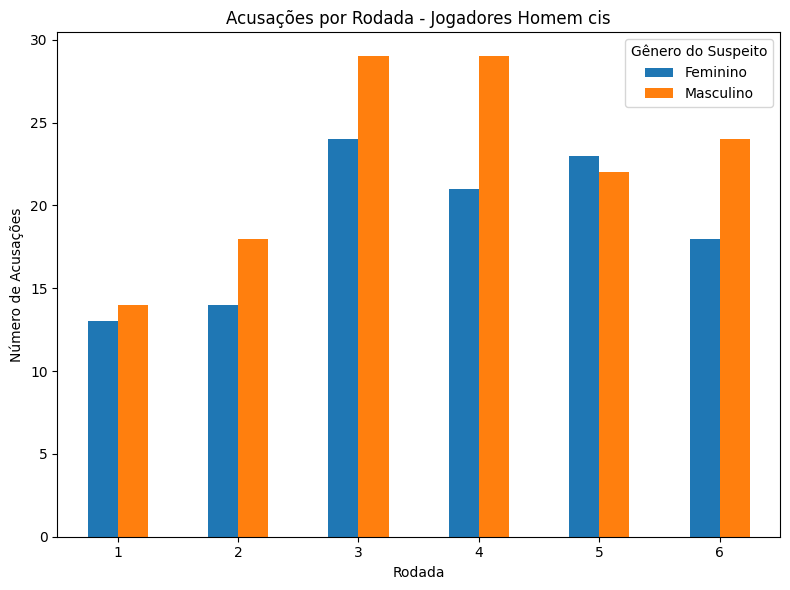

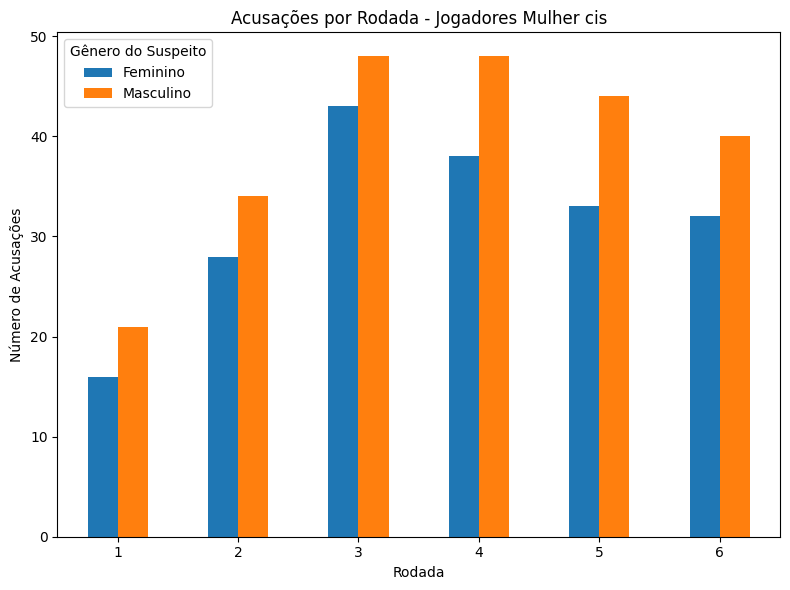

In [6]:
# Contar acusações (Decisao_Final == 1) por rodada para cada gênero de jogador
df_acusacoes_por_rodada = df[df['Decisao_Final'] == 1]

# Função para plotar gráfico separado por gênero do jogador
def plot_acusacoes_por_rodada(genero_jogador):
    subset = df_acusacoes_por_rodada[df_acusacoes_por_rodada['Genero_Participante'] == genero_jogador]
    contagem = subset.groupby(['Num_Rodada', 'Genero_Suspeito']).size().unstack(fill_value=0)

    contagem.plot(kind='bar', figsize=(8,6))
    plt.title(f"Acusações por Rodada - Jogadores {genero_jogador}")
    plt.ylabel("Número de Acusações")
    plt.xlabel("Rodada")
    plt.xticks(rotation=0)
    plt.legend(title="Gênero do Suspeito")
    plt.tight_layout()
    plt.show()

# Plot para homens cis
plot_acusacoes_por_rodada("Homem cis")

# Plot para mulheres cis
plot_acusacoes_por_rodada("Mulher cis")


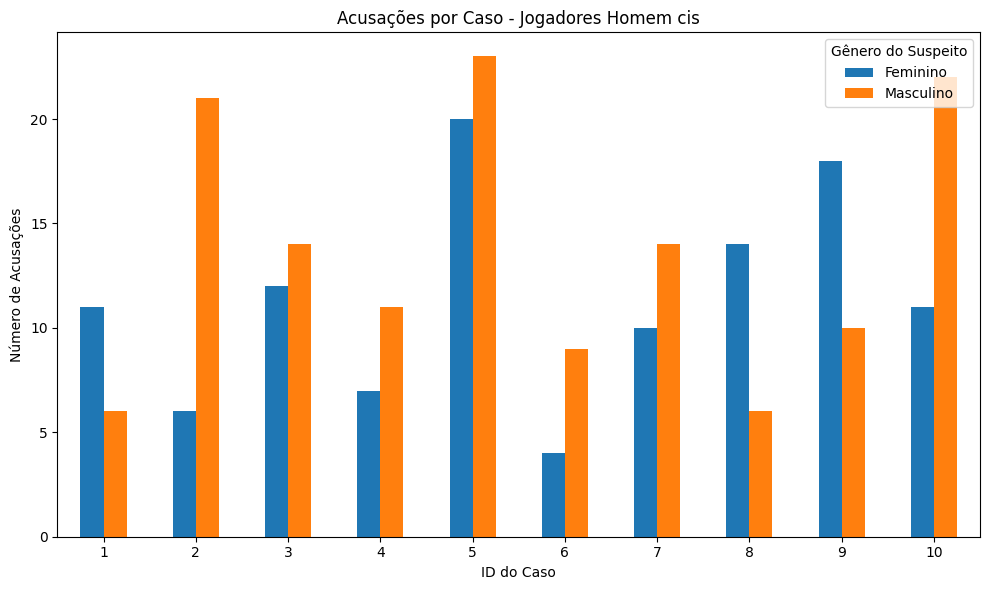

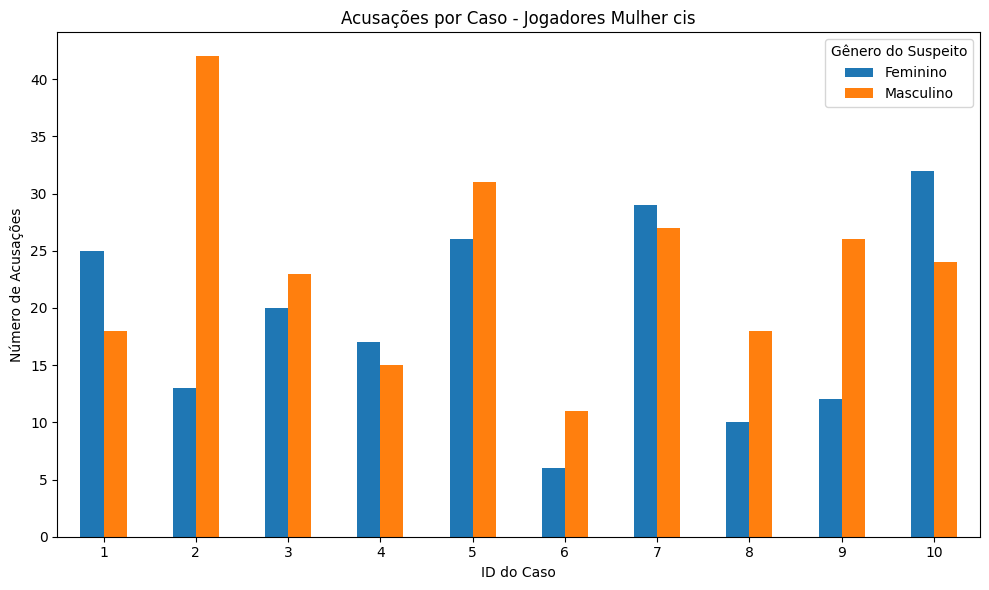

In [7]:
import matplotlib.pyplot as plt

# Filtrar apenas acusações
df_acusacoes = df[df['Decisao_Final'] == 1]

# Função para gerar gráfico por caso
def plot_acusacoes_por_caso(genero_jogador):
    subset = df_acusacoes[df_acusacoes['Genero_Participante'] == genero_jogador]
    contagem = subset.groupby(['ID_Caso', 'Genero_Suspeito']).size().unstack(fill_value=0)

    contagem.plot(kind='bar', figsize=(10,6))
    plt.title(f"Acusações por Caso - Jogadores {genero_jogador}")
    plt.ylabel("Número de Acusações")
    plt.xlabel("ID do Caso")
    plt.xticks(rotation=0)
    plt.legend(title="Gênero do Suspeito")
    plt.tight_layout()
    plt.show()

# Gráfico para homens cis
plot_acusacoes_por_caso("Homem cis")

# Gráfico para mulheres cis
plot_acusacoes_por_caso("Mulher cis")


                     Testemunhal  Documental  Material  Pericial  Indiciária  \
Genero_Participante                                                            
Homem cis                     60          97        78       104         111   
Mulher cis                   105         169       124       173         188   

                     Álibi  
Genero_Participante         
Homem cis               52  
Mulher cis              94  


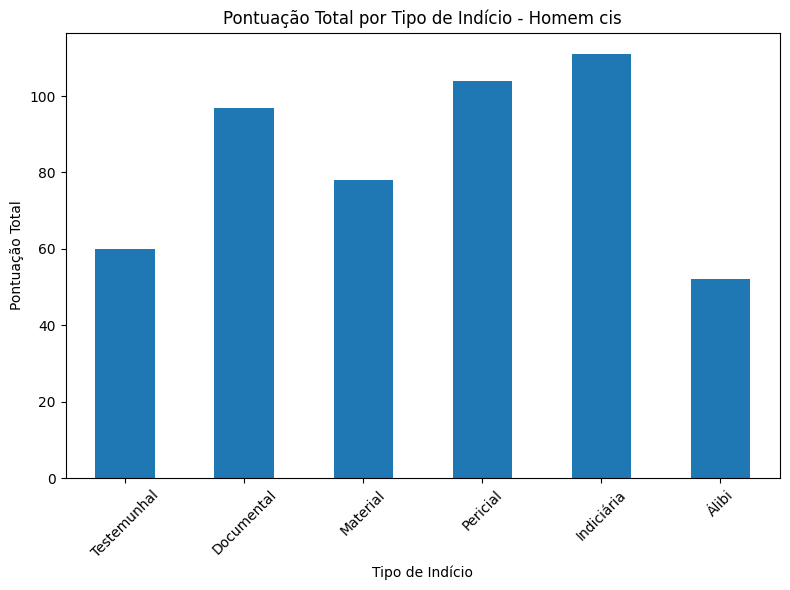

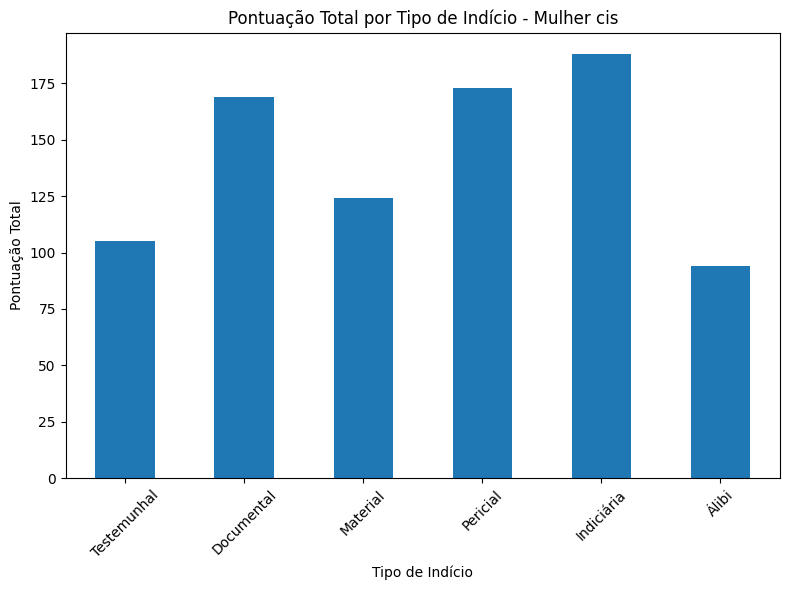

In [8]:
# Garantir que Decisao_Final seja numérica
df['Decisao_Final'] = pd.to_numeric(df['Decisao_Final'], errors='coerce')

# =========================
# 2. Filtrar apenas a última rodada
# =========================
df_final = df[df['Num_Rodada'] == 6].copy()

# =========================
# 3. Matriz de pesos dos indícios
# =========================
pesos = {
    1: {"Testemunhal": 2, "Documental": 1, "Material": 1, "Pericial": 3, "Indiciária": 2, "Álibi": 2},
    2: {"Testemunhal": 1, "Documental": 3, "Material": 1, "Pericial": 1, "Indiciária": 2, "Álibi": 3},
    3: {"Testemunhal": 1, "Documental": 2, "Material": 3, "Pericial": 3, "Indiciária": 3, "Álibi": 1},
    4: {"Testemunhal": 2, "Documental": 3, "Material": 1, "Pericial": 1, "Indiciária": 2, "Álibi": 2},
    5: {"Testemunhal": 2, "Documental": 1, "Material": 3, "Pericial": 3, "Indiciária": 2, "Álibi": 1},
    6: {"Testemunhal": 2, "Documental": 3, "Material": 1, "Pericial": 1, "Indiciária": 2, "Álibi": 3},
    7: {"Testemunhal": 1, "Documental": 3, "Material": 1, "Pericial": 2, "Indiciária": 3, "Álibi": 1},
    8: {"Testemunhal": 3, "Documental": 1, "Material": 1, "Pericial": 3, "Indiciária": 2, "Álibi": 2},
    9: {"Testemunhal": 1, "Documental": 3, "Material": 1, "Pericial": 3, "Indiciária": 3, "Álibi": 1},
    10: {"Testemunhal": 2, "Documental": 3, "Material": 1, "Pericial": 2, "Indiciária": 3, "Álibi": 1},
}

# =========================
# 4. Criar colunas de pontuação
# =========================
tipos_indicio = ["Testemunhal", "Documental", "Material", "Pericial", "Indiciária", "Álibi"]
for tipo in tipos_indicio:
    df_final[tipo] = 0

# Atribuir pontos apenas para quem votou "culpado"
for idx, row in df_final.iterrows():
    if row['Decisao_Final'] == 1:
        caso = row['ID_Caso']
        for tipo in tipos_indicio:
            df_final.at[idx, tipo] = pesos[caso][tipo]

# =========================
# 5. Somar pontos por gênero
# =========================
soma_pontos = df_final.groupby("Genero_Participante")[tipos_indicio].sum()
print(soma_pontos)

# =========================
# 6. Plotar gráficos
# =========================
for genero in soma_pontos.index:
    soma_pontos.loc[genero].plot(kind='bar', figsize=(8,6))
    plt.title(f"Pontuação Total por Tipo de Indício - {genero}")
    plt.ylabel("Pontuação Total")
    plt.xlabel("Tipo de Indício")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

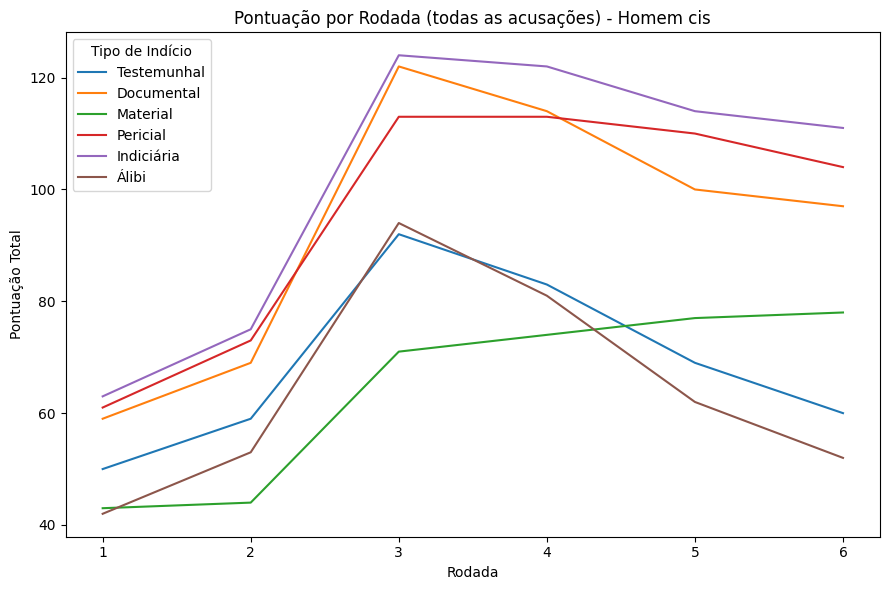

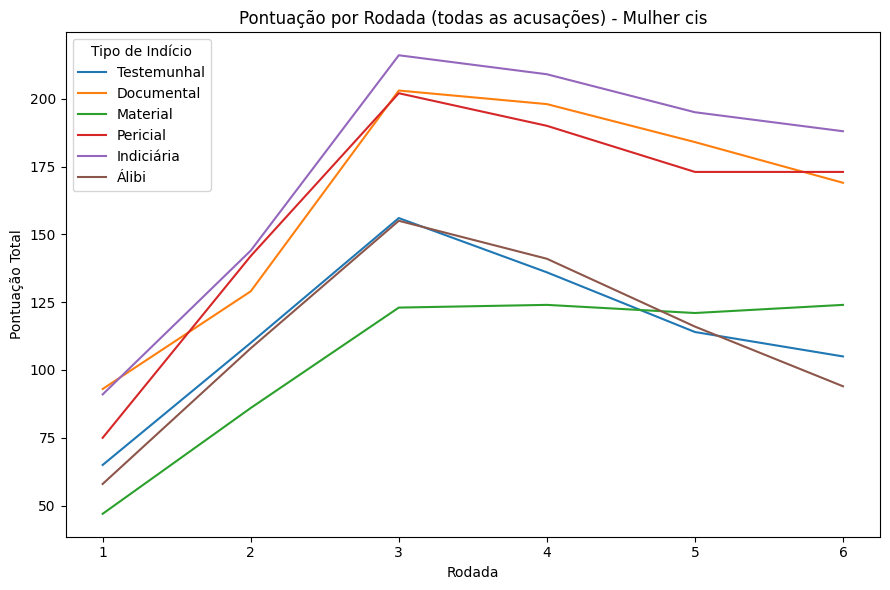

In [9]:
# =========================
# 7. Pontuação ROUND A ROUND (todas as rodadas com voto "culpado")
# =========================

# partimos do df original (todas as rodadas)
df_round = df.copy()

# cria colunas de pontuação zeradas
for tipo in tipos_indicio:
    df_round[tipo] = 0

# aplica pesos do caso somente nas linhas com voto "culpado"
mask_culpado = df_round['Decisao_Final'] == 1
for caso, w in pesos.items():
    mask_caso = df_round['ID_Caso'] == caso
    mask = mask_culpado & mask_caso
    for tipo in tipos_indicio:
        df_round.loc[mask, tipo] = w[tipo]

# agrega pontuação por gênero e por rodada
scores_round = (
    df_round.groupby(['Genero_Participante', 'Num_Rodada'])[tipos_indicio]
            .sum()
            .reset_index()
            .sort_values('Num_Rodada')
)

# função para plotar 1 gráfico por gênero com linhas para cada tipo de indício
def plot_scores_round(genero):
    dados = (
        scores_round[scores_round['Genero_Participante'] == genero]
        .set_index('Num_Rodada')[tipos_indicio]
    )
    ax = dados.plot(figsize=(9, 6))  # uma linha por tipo de indício
    ax.set_title(f"Pontuação por Rodada (todas as acusações) - {genero}")
    ax.set_xlabel("Rodada")
    ax.set_ylabel("Pontuação Total")
    ax.set_xticks(range(1, 7))
    ax.legend(title="Tipo de Indício")
    plt.tight_layout()
    plt.show()

# gráficos separados
plot_scores_round("Homem cis")
plot_scores_round("Mulher cis")


Pontuação total por tipo de indício (somando todas as rodadas):
                     Testemunhal  Documental  Material  Pericial  Indiciária  \
Genero_Participante                                                            
Homem cis                    413         561       387       574         609   
Mulher cis                   686         976       625       955        1043   

                     Álibi  
Genero_Participante         
Homem cis              384  
Mulher cis             672  


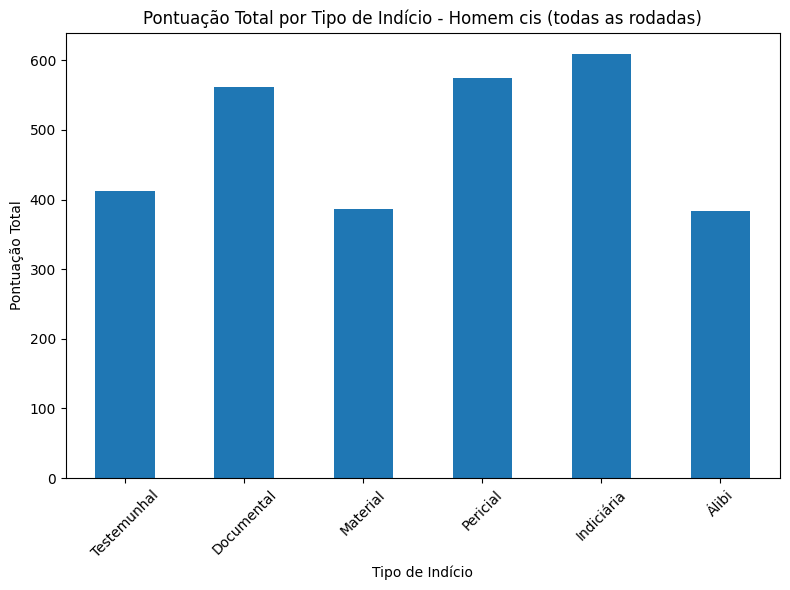

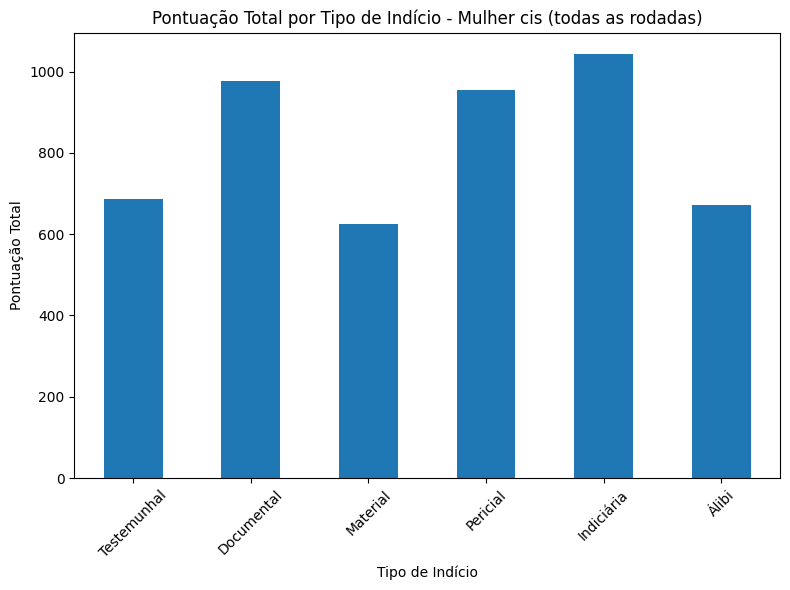

In [10]:
# =========================
# 7. Mesmo gráfico, mas somando TODAS as rodadas
# =========================

# Partimos do df original (todas as rodadas)
df_all = df.copy()

# Zera/Cria as colunas de pontuação
for tipo in tipos_indicio:
    df_all[tipo] = 0

# Aplica os pesos do caso em TODAS as linhas com voto "culpado"
mask_culpado = df_all['Decisao_Final'] == 1
for caso, w in pesos.items():
    mask_caso = df_all['ID_Caso'] == caso
    mask = mask_culpado & mask_caso
    for tipo in tipos_indicio:
        df_all.loc[mask, tipo] = w[tipo]

# Soma por gênero (agora considerando todas as rodadas)
soma_pontos_todas = df_all.groupby("Genero_Participante")[tipos_indicio].sum()
print("\nPontuação total por tipo de indício (somando todas as rodadas):")
print(soma_pontos_todas)

# Plota os mesmos gráficos por gênero (eixo X = tipos de indício)
for genero in soma_pontos_todas.index:
    ax = soma_pontos_todas.loc[genero].plot(kind='bar', figsize=(8,6))
    ax.set_title(f"Pontuação Total por Tipo de Indício - {genero} (todas as rodadas)")
    ax.set_ylabel("Pontuação Total")
    ax.set_xlabel("Tipo de Indício")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()